## This is the random Sparsity Notebook.. This notebook injects random sparsity in air quality indicators and benchmark how sequence2Sequece model perform as the sparsity level increases..

In [3]:
'''Import all the standard preprocessing package that is needed.. from all_imports.py'''

import all_imports as ai 


In [ ]:
# import importlib
# import revise_baseline
# importlib.reload(revise_baseline)


<module 'revise_baseline' from 'c:\\mythesis_work\\revise_baseline.py'>

In [191]:
'''import the data prepartion code from custom_function.py'''
from random_sparsity_induce import (inject_pollutant_sparsity_df, compare_sparsity, verify_sparsity)

from Seq2Se2_baseline import (SequenceToSequenceModel, ForecastPipeline)
from Seq2Seq_data_prep import (prepare_sequence_data, prepare_data)


In [ ]:
''' Takes the configuration of the model'''

config = {
    "input_len": 24,          
    "output_len": 24,         
    "input_features": 18,    
    "target_features": 1,   
    "hidden_size": 128,
    "num_layers": 2,
    "dropout_rate": 0.3,
    "target_index": 0,  
    "deco_input_features": 1,   
    "epochs": 1,           
}

In [192]:
''''  #load the cleaned data'''

data = ai.pd.read_csv("clean_data.csv", index_col=0) 

In [193]:
data.index = ai.pd.to_datetime(data.index)

In [195]:
pollutant_columns = ['CO', 'O3', 'NO2', 'PMI-10', 'SO2', 'PMI-2.5'] #sparsity at 15%... 
sparse_df, mask_df = inject_pollutant_sparsity_df(data, pollutant_columns, sparsity_level=0.15)

In [196]:
'''sanity check.. examine the numbers of zeros in original vs sparse dataframes'''
compare_sparsity(data, sparse_df, pollutant_columns)



,Original Zeros,Sparse Zeros,original_sparsity(%),sparsity_zero(%)
CO,28.0,3937.0,0.11,14.97
O3,580.0,4475.0,2.20,17.01
NO2,210.0,4052.0,0.80,15.40
PMI-10,508.0,4455.0,1.93,16.94
SO2,5109.0,8336.0,19.42,31.69
PMI-2.5,1163.0,4879.0,4.42,18.55


In [197]:
''' check the sparsity percentage in the sparse dataframe.. Unfortunately this code is reduducant as the first code already does it..'''

verify_sparsity(sparse_df, pollutant_columns)

,Zero Counts,Sparsity (%)
CO,3937.0,14.97
O3,4475.0,17.01
NO2,4052.0,15.40
PMI-10,4455.0,16.94
SO2,8336.0,31.69
PMI-2.5,4879.0,18.55


In [ ]:
# CO, NO2, PMI-10

1.7.2


In [198]:
''' Prepare the data for the first model.. NO2'''
df = prepare_data(sparse_df, target_col='CO')  #prepare the sparse data for NO2

In [199]:
# del(seq2seq_model)
(X_enc_train, X_dec_train, Y_train,
 X_enc_val, X_dec_val, Y_val,
 X_enc_test, X_dec_test, Y_test,
 scalers_test, target_column_name, output_seq_len) = prepare_sequence_data(df, input_seq_len=config["input_len"], output_seq_len=config["output_len"], target_indices=[0], split_ratio=(0.7, 0.85))

# Test to make sure the pipeline works

287/287 ━━━━━━━━━━━━━━━━━━━━ 43s 76ms/step - loss: 1.5097 - mae: 0.9221 - val_loss: 0.9598 - val_mae: 0.6752

📊 Evaluation on Inverse-Transformed Test Set:
MAE   = 59.7180
MAPE  = 18.9636%
SMAPE = 45.4858%
MSE   = 7781.3464
RMSE  = 88.2119
Sparsity_level: 50%_Random_Sparsity_48_FH


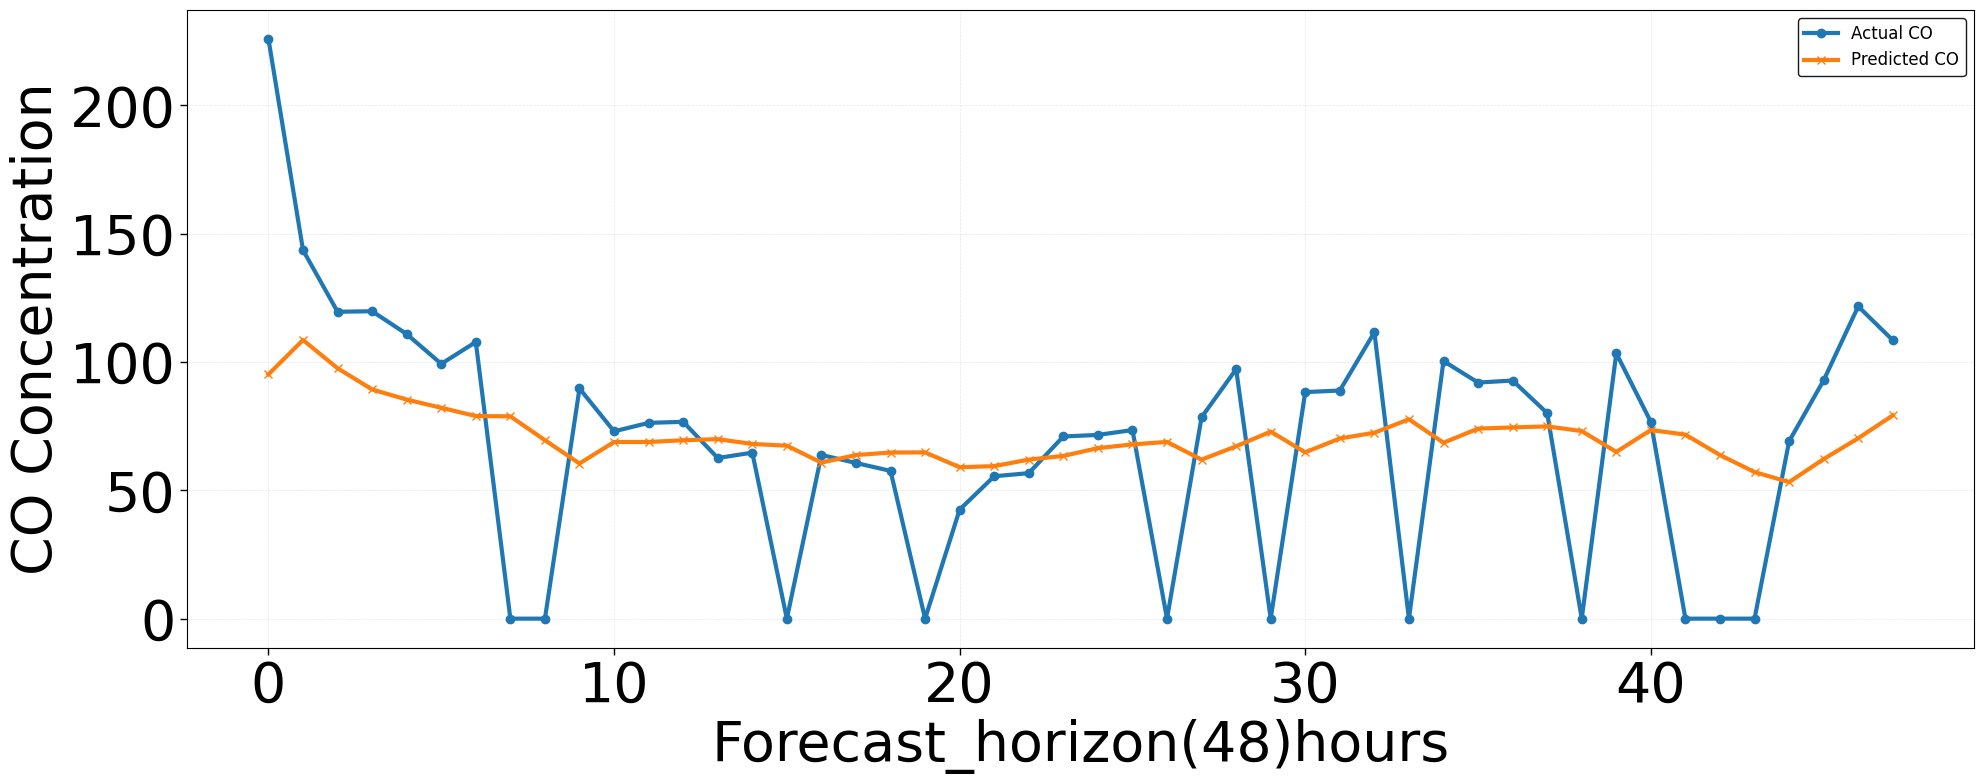

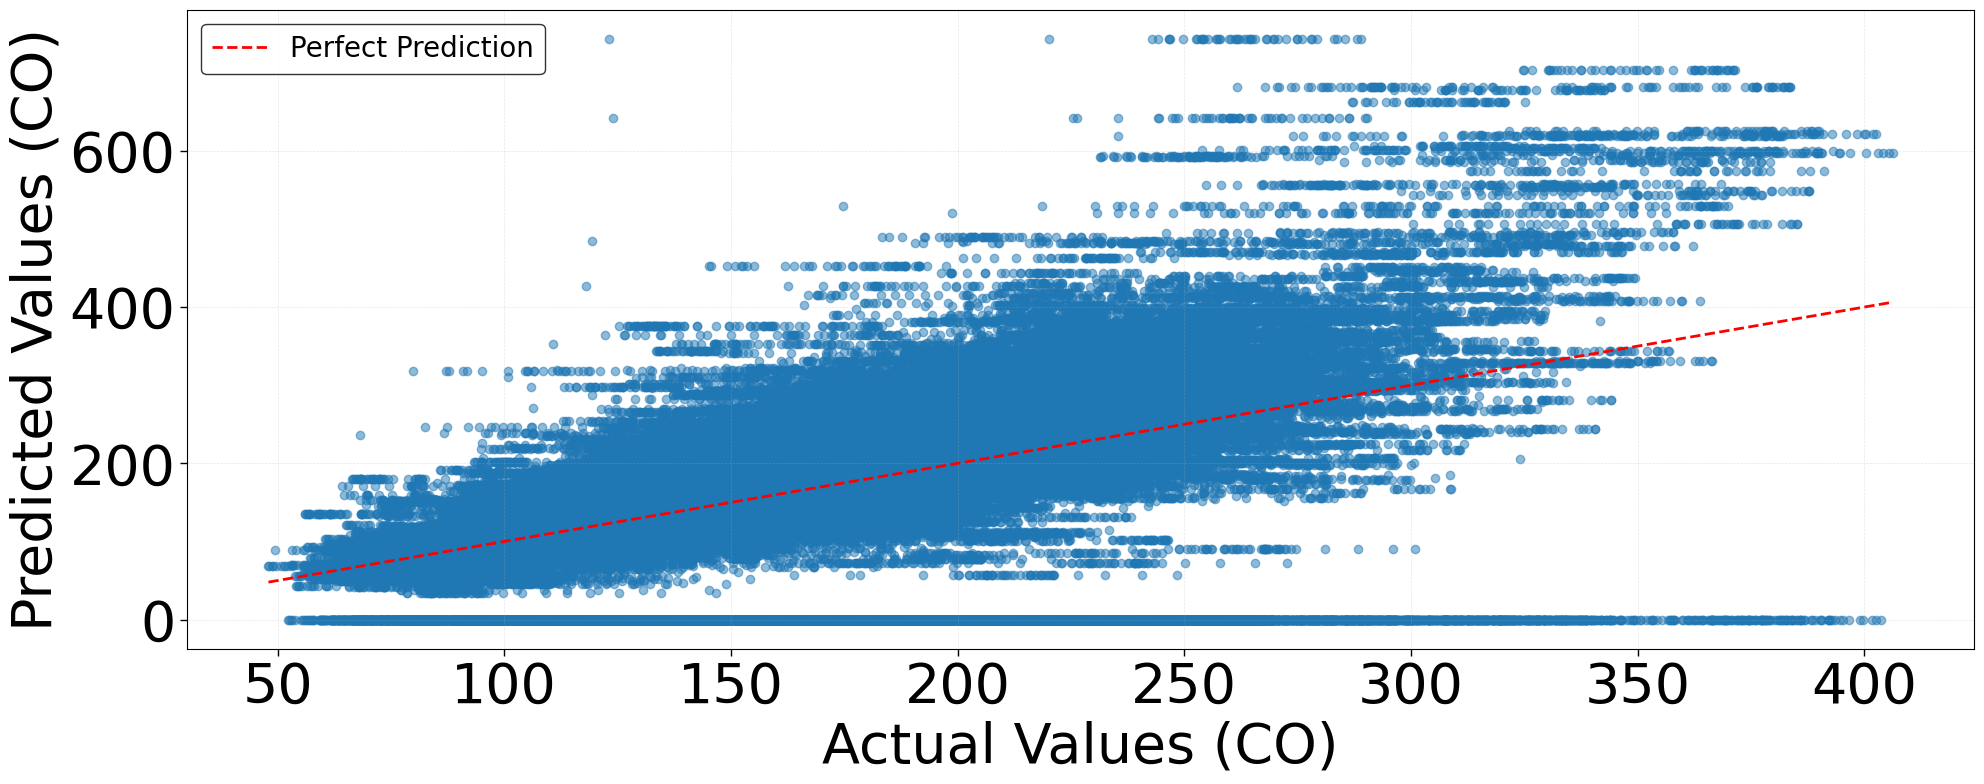

In [200]:
model = SequenceToSequenceModel(enc_units=64, dec_units=64, output_dim=1, dropout_rate=0.3)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

pipeline = ForecastPipeline(model, sparsity_level="50%_Random_Sparsity_48_FH", scaler_list=scalers_test)

# Traindsfjdsjsadkd

history = pipeline.train_model(X_enc_train, X_dec_train, Y_train,
                             X_enc_val, X_dec_val, Y_val,
                               batch_size=64, epochs=1, patience=5)

# Evaluate
Y_true, Y_pred = pipeline.evaluate_model(X_enc_test, X_dec_test, Y_test)

# Metrics
metrices = pipeline.compute_metrics(Y_true, Y_pred, target_column_name)
#save_path= f"results_plot/forecasting_baseline_{target_column_name}_{output_seq_len}
# Plot
pipeline.plot_forecast(Y_true, Y_pred, target_column_name, output_seq_len)
#save_path= f"results_plot/error_ditsri_baseline_{target_column_name}_{output_seq_len}",
pipeline.plot_error_distribution(Y_pred, Y_true, target_column_name,  show_histogram=False)

In [201]:
''' Takes the configuration of the model'''

config = {
    "input_len": 24,          
    "output_len": 24,         
    "input_features": 18,    
    "target_features": 1,   
    "hidden_size": 128,
    "num_layers": 2,
    "dropout_rate": 0.3,
    "target_index": 0,  
    "deco_input_features": 1,   
    "epochs": 1,           
}

In [202]:
def objective(trial):
    # 📊 Sample hyperparameters
    config = {"enc_units": trial.suggest_int("enc_units", 32, 128),
              "dec_units" :trial.suggest_int("dec_units", 32, 128),
              "dropout_rate": trial.suggest_float("dropout_rate", 0.1, 0.5),
              "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True),
              "batch_size": trial.suggest_categorical("batch_size", [32, 64, 128]),
              "epochs": trial.suggest_int("epochs", 1, 2)}
   

    # 🧠 Build model
    model = SequenceToSequenceModel(
        enc_units=config["enc_units"],
        dec_units=config["dec_units"],
        output_dim=1,
        dropout_rate=config["dropout_rate"]
    )
    model.compile(optimizer=ai.tf.keras.optimizers.Adam(learning_rate=config["learning_rate"]),
                  loss='mse', metrics=['mae'])

    # 🔁 Train
    pipeline = ForecastPipeline(model, scaler_list=scalers_test)
    history = pipeline.train_model(
        X_enc_train, X_dec_train, Y_train,
        X_enc_val, X_dec_val, Y_val,
        batch_size=config["batch_size"],
        epochs=config["epochs"],
        patience=5
    )

    # 📉 Evaluate on validation set
    val_loss = min(history.history['val_mae'])  # or 'val_loss' if preferred

    return val_loss

In [207]:
def optimise_and_extract():
    study_sparsity = ai.optuna.create_study(direction="minimize")
    study_sparsity.optimize(objective, n_trials=1)

    best_params_sparsity = study_sparsity.best_trial.params
    best_params_sprasity = study_sparsity.best_trial.params
    print("Best MAE:", study_sparsity.best_trial.value)
    print("Best hyperparameters:", best_params_sparsity)
    best_config_sparsity = { "best_enc_units": best_params_sprasity["enc_units"],
               "best_dec_units": best_params_sprasity["dec_units"],
               "best_dropout": best_params_sprasity["dropout_rate"],
               "best_lr": best_params_sprasity["learning_rate"],
               "best_epoch": best_params_sprasity["epochs"], 
               "best_batch_size": best_params_sprasity["batch_size"]}
    model = SequenceToSequenceModel(
        enc_units=best_config_sparsity["best_enc_units"],
        dec_units=best_config_sparsity["best_dec_units"],
        output_dim=1,
        dropout_rate=best_config_sparsity["best_dropout"])

    model.compile(
        optimizer=ai.tf.keras.optimizers.Adam(learning_rate=best_config_sparsity["best_lr"]),
        loss='mse',
        metrics=['mae'])
    pipeline = ForecastPipeline(model, sparsity_level="50%_Random_Sparsity_48_FH", scaler_list=scalers_test)

    history = pipeline.train_model(
        X_enc_train, X_dec_train, Y_train,
        X_enc_val, X_dec_val, Y_val,
        batch_size=best_config_sparsity["best_batch_size"],
        epochs=best_config_sparsity["best_epoch"],
        patience=5
        )
    

    return model, best_params_sparsity

In [208]:
model, best_params_sprasity = optimise_and_extract()



[I 2025-11-20 20:05:10,707] A new study created in memory with name: no-name-2dd11445-0721-400c-a19b-f180de145bf1


Epoch 1/2
574/574 ━━━━━━━━━━━━━━━━━━━━ 85s 102ms/step - loss: 1.0127 - mae: 0.7013 - val_loss: 0.9337 - val_mae: 0.7065
Epoch 2/2
574/574 ━━━━━━━━━━━━━━━━━━━━ 54s 93ms/step - loss: 0.9219 - mae: 0.6635 - val_loss: 0.9092 - val_mae: 0.6619


[I 2025-11-20 20:07:30,082] Trial 0 finished with value: 0.6619042754173279 and parameters: {'enc_units': 125, 'dec_units': 61, 'dropout_rate': 0.3729147648576897, 'learning_rate': 0.00928425309280977, 'batch_size': 32, 'epochs': 2}. Best is trial 0 with value: 0.6619042754173279.


Best MAE: 0.6619042754173279
Best hyperparameters: {'enc_units': 125, 'dec_units': 61, 'dropout_rate': 0.3729147648576897, 'learning_rate': 0.00928425309280977, 'batch_size': 32, 'epochs': 2}
Epoch 1/2
574/574 ━━━━━━━━━━━━━━━━━━━━ 52s 66ms/step - loss: 1.0214 - mae: 0.7054 - val_loss: 0.9324 - val_mae: 0.7250
Epoch 2/2
574/574 ━━━━━━━━━━━━━━━━━━━━ 46s 80ms/step - loss: 0.9106 - mae: 0.6585 - val_loss: 0.8895 - val_mae: 0.6612



📊 Evaluation on Inverse-Transformed Test Set:
MAE   = 59.7180
MAPE  = 18.9636%
SMAPE = 45.4858%
MSE   = 7781.3464
RMSE  = 88.2119
Sparsity_level: 50%Random_Sparsity_48_FH


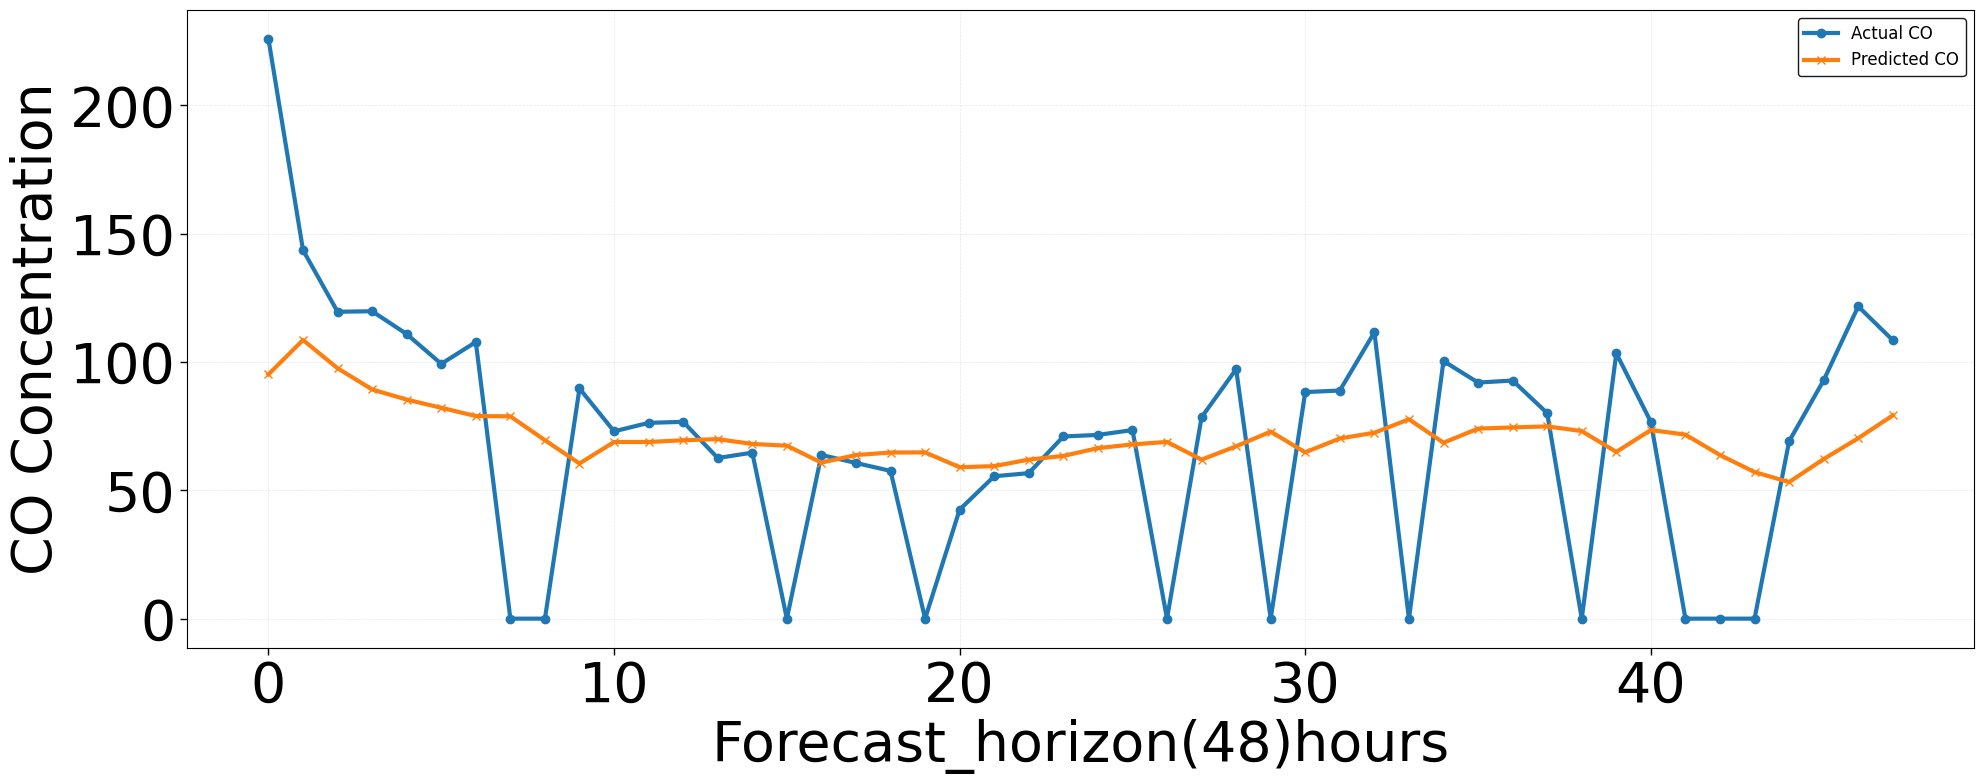

c:\mythesis_work\Seq2Se2_baseline.py:166: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(fontsize=20, loc='upper left', frameon=True, framealpha=0.8)


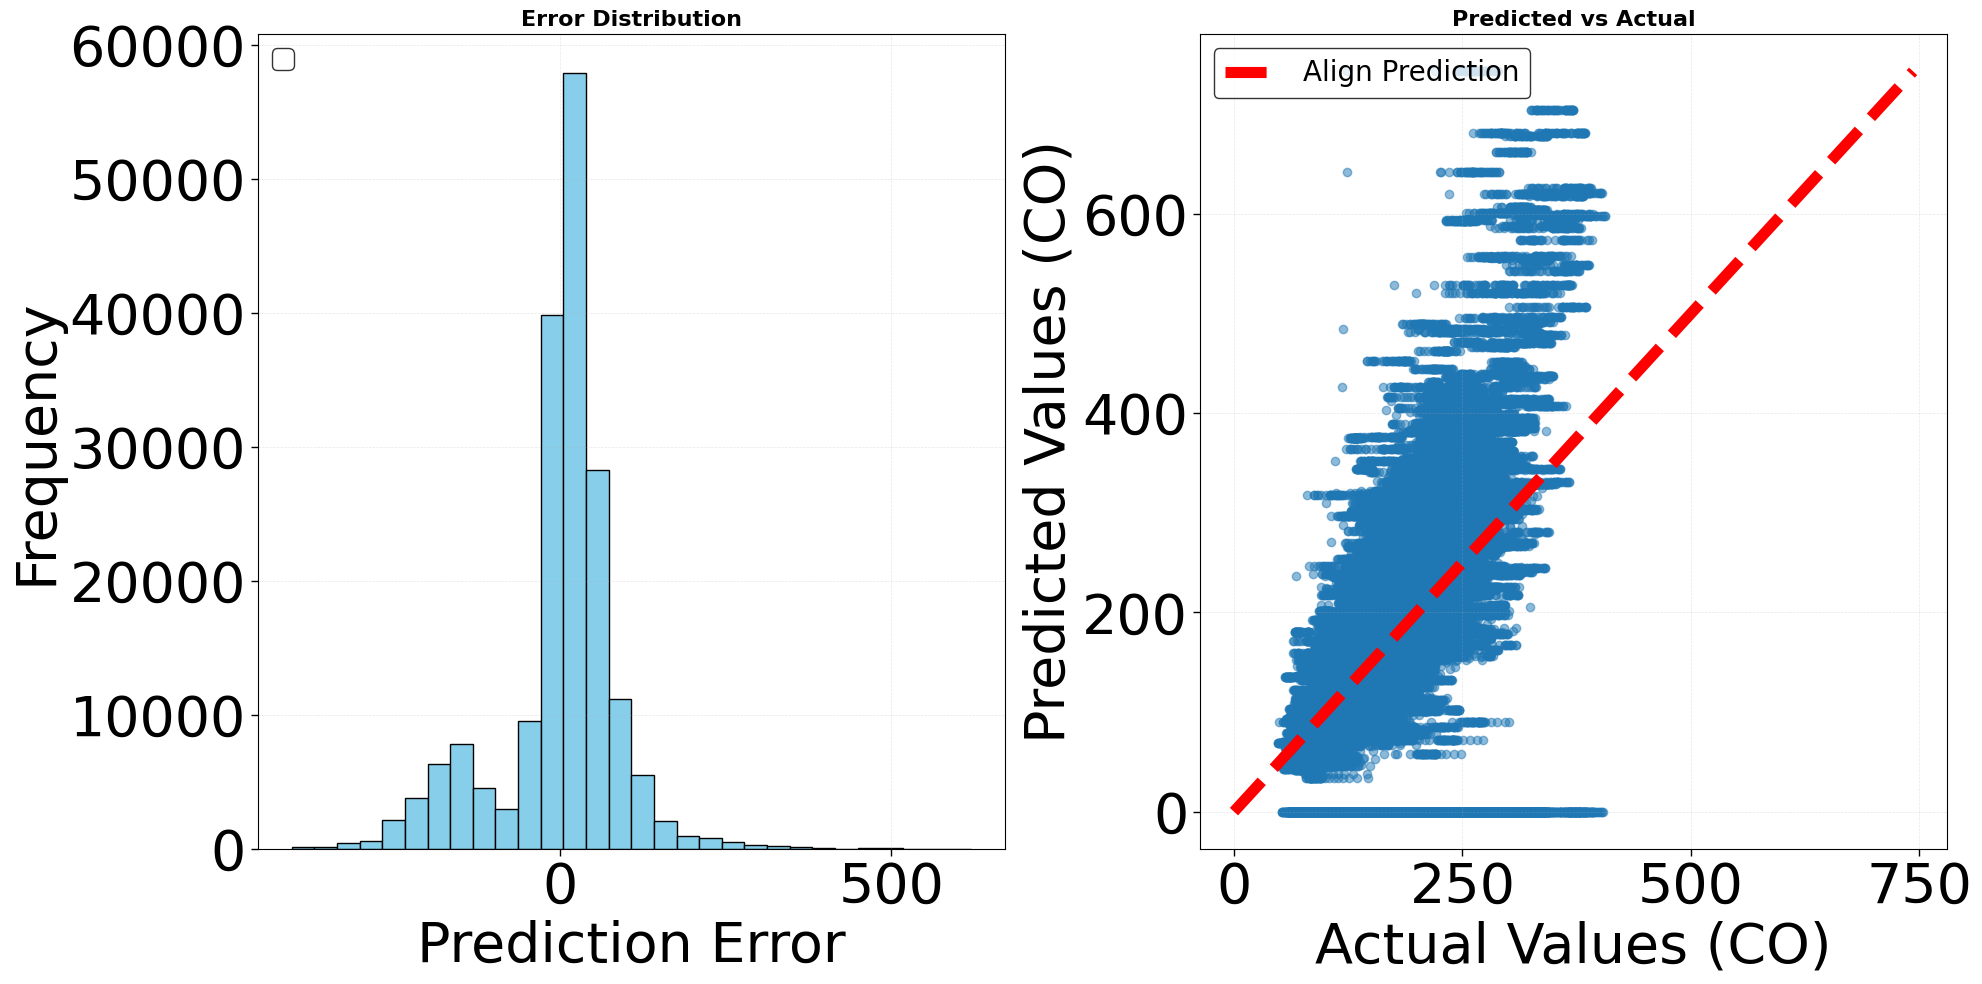

In [211]:
pipeline_sparsity = ForecastPipeline(model, sparsity_level="50%Random_Sparsity_48_FH", scaler_list=scalers_test)
Y_true, Y_pred = pipeline.evaluate_model(X_enc_test, X_dec_test, Y_test)
# pipeline.compute_metrics(Y_true, Y_pred)
# pipeline.plot_forecast(Y_true, Y_pred, target_column_name)
# pipeline.plot_error_distribution(Y_true, Y_pred, target_column_name, show_histogram=False)
# Metrics
metrices_sparsity = pipeline_sparsity.compute_metrics(Y_true, Y_pred, target_column_name)

# Plot
# save_path= f"results_plot/forecasting_baseline_{target_column_name}_{output_seq_len}"

pipeline_sparsity.plot_forecast(Y_true, Y_pred, target_column_name, output_seq_len)

pipeline_sparsity.plot_error_distribution(Y_pred, Y_true, target_column_name,  show_histogram=True)
#save_path= f"results_plot/error_ditsri_25%_Sparsity_{target_column_name}_{output_seq_len}",
#save_path= f"results_plot/error_ditsri_baseline_{target_column_name}_{output_seq_len}"
# pipeline.plot_training_history(history, highlight_best=True, smooth=True)
#save_path= f"results_plot/forecasting_25%_Sparsity_{target_column_name}_{output_seq_len}"

In [183]:
metrices_sparsity

{'MAE': 9.1824,
 'MAPE %': 47.7254,
 'SMAPE %': 130.0052,
 'RMSE': 10.581,
 'Sparsity_Type': '50%Random_Sparsity_48_FH',
 'Polluntant_name': 'PMI-10'}

In [ ]:
combined_sparsity = {**metrices_sparsity, **best_params_sprasity} # Merge both dictionaries
# results_baseline = ai.pd.DataFrame.from_dict(combined_baseline, orient="index").T 
# results_baseline.to_csv("baseline.csv", index=False)

In [185]:
sparsity = ai.pd.DataFrame.from_dict(combined_sparsity, orient="index").T
sparsity.to_csv("baseline.csv", mode="a", header=False, index=False)

In [186]:
sparsity = ai.pd.read_csv("baseline.csv")
